# Caio Vasconcelos Silva Andrade

## Notebook --> Simulated Annealing (Notas pessoais)

### Uma especie de "evolução" do hill climbing

### Iremos reaproveitar o tweak do hill climbing!

### USEI COMO BASE: [Simulated Annealing](https://sites.icmc.usp.br/sandra/G9_t2/annealing.htm)

## Imports

In [1]:
import pymoo.gradient.toolbox as anp
import numpy as np
import matplotlib.pyplot as plt
import math
import random

## Sphere e Ackley

In [2]:
from pymoo.core.problem import Problem
class Sphere:
    def __init__(self, n_var=10):
        self.n_var = n_var
        self.bounds = [-100, 100]
        
    def evaluate2(self, x):
        return np.sum(x**2)

    def evaluate(self, x):
        return np.sum((x - 0.5) ** 2)
    
class Ackley:
    def __init__(self, n_var=2, a=20, b=0.2, c=2*np.pi):
        self.n_var = n_var
        self.a = a
        self.b = b
        self.c = c
        self.bounds = [-100, 100]  # Domínio típico da função Ackley

    def evaluate(self, x):
        """Calcula o valor da função Ackley para um ponto x"""
        # Para lidar com múltiplos pontos (matriz) ou um único ponto (vetor)
        if x.ndim == 1:
            x = x.reshape(1, -1)
            
        sum_sq = np.sum(x**2, axis=1)
        sum_cos = np.sum(np.cos(self.c * x), axis=1)
        
        term1 = -self.a * np.exp(-self.b * np.sqrt(sum_sq / self.n_var))
        term2 = -np.exp(sum_cos / self.n_var)
        
        return term1 + term2 + self.a + np.exp(1)


# Hill Climbing

## Tweak

Ja temos tudo explicado no notebook 1 de Hill Climbing!

In [3]:
def bounded_uniform_convolution(v, p=1, r=10, min_val=-100, max_val=100):
    tweaked = v.copy()
    for i in range(len(tweaked)):
        if np.random.random() <= p:  # Probabilidade p de modificar este elemento
            while True:
                noise = np.random.uniform(-r, r)  # Ruído entre -r e r
                new_value = tweaked[i] + noise
                if min_val <= new_value <= max_val:  # Verifica limites
                    tweaked[i] = new_value
                    break
    return tweaked

In [4]:
def hill_climbing(func, initial, max_evaluations=50000, step_size=10, p = 0.9):
    current = initial.copy() # Faz uma copia do vetor X inicial
    current_eval = func.evaluate(current) # Ele vai vai rodar a funcao (No caso da esfere ele vai somar o quadrado dos elementos do vetor X)
    evaluations = 1 # Contador de avaliações
    history = [current_eval] # Histórico de avaliações (Apenas para fins de voltar depois e avaliar)

    # Enquanto houver avaliações disponíveis (For menos que o valor que definimos)
    while evaluations < max_evaluations:
        # CORREÇÃO: Gerar múltiplos vizinhos usando bounded_uniform_convolution
        neighbors = [bounded_uniform_convolution(current, p=p, r=step_size, min_val=func.bounds[0], max_val=func.bounds[1])] #for _ in range(20)]  # Gera 20 vizinhos
        neighbor_evals = [func.evaluate(n) for n in neighbors] # Roda a funcao
        evaluations += len(neighbors) # Atualiza o contador de avaliações (Agora são 20 vizinhos por iteração)
        best_idx = np.argmin(neighbor_evals) # Minimização (queremos o menor valor da função) (Ele retorna o índice do melhor vizinho (argmin))
        
        if neighbor_evals[best_idx] < current_eval: # Se encontrarmos um vizinho melhor
            current = neighbors[best_idx] # Atualiza o ponto atual
            current_eval = neighbor_evals[best_idx] # Atualiza a avaliação atual
            history.append(current_eval) # Adiciona a nova avaliação ao histórico
        # else: # Se não encontrarmos um vizinho melhor, reduzimos o passo
        #     step_size *= 0.90
        #     if step_size < 0.001:  # Critério mais rigoroso
        #         break  # Para se o passo ficar muito pequeno

    return current, current_eval, history # Current é o melhor ponto encontrado, current_eval é seu valor e history é o histórico de avaliações

### Sphere

In [5]:
sphere = Sphere(n_var=10)
resultados_sphere = [] # Lista de resultados_sphere2

for i in range(20):
    X = np.random.uniform(-100, 100, sphere.n_var) # Esse é nosso X
    a,b,c = hill_climbing(sphere, X, step_size=0.5, p=0.1)
    resultados_sphere.append(b)

    #print(f"Rodada {i+1} tivemos um valor minimizado de {b:.5f} \n Com um vetor minimizado de: \n{a}")

min_value = min(resultados_sphere)
print(f"\nO melhor valor minimizado que conseguimos foi {min_value} da rodada {resultados_sphere.index(min_value) + 1}")


O melhor valor minimizado que conseguimos foi 3.7773227605758313e-07 da rodada 16


### Ackley

In [6]:
ack = Ackley(n_var=10)
resultados_ack = [] # Lista de resultados_ack2

for i in range(20):
    X = np.random.uniform(-100, 100, ack.n_var) # Esse é nosso X
    a,b,c = hill_climbing(ack, X, p=0.5, step_size=10)
    resultados_ack.append(b)

    #print(f"Rodada {i+1} tivemos um valor minimizado de {b}")

print(f"\nO melhor valor minimizado que conseguimos foi {min(resultados_ack)}")


O melhor valor minimizado que conseguimos foi [19.97595607]


# Simulated Annealing

Simulated Annealing (SA) pode ser visto como uma evolução do Hill Climbing que inclui um mecanismo para aceitar soluções "inferiores" de forma probabilística, e não apenas soluções melhores como no Hill Climbing tradicional.

A principal diferença está justamente na aceitação probabilística de movimentos que pioram a solução, o que permite ao algoritmo escapar de ótimos locais - algo que o Hill Climbing não consegue fazer por não permitir "passos para baixo". 

Temperatura: Quando a temperatura está alta, o algoritmo se comporta mais como um "random walk", aceitando muitas soluções piores para explorar amplamente o espaço de soluções. Conforme a temperatura diminui, ele passa a se comportar cada vez mais como um Hill Climbing, focando na exploração de regiões promissoras. 

Este comportamento dinâmico é exatamente o que torna o Simulated Annealing melhor para problemas complexos com muitos ótimos locais, enquanto o Hill Climbing tende a ficar preso no primeiro ótimo local que encontra. 

Uma observação técnica importante: a probabilidade de aceitar uma solução pior é geralmente calculada usando a fórmula de Metropolis: exp(-ΔE/T), onde ΔE é a degradação da solução e T é a temperatura atual. Essa função de aceitação probabilística é o coração do algoritmo.

In [7]:
def simulated_annealing(func, initial, max_evaluations=50000, initial_temp=1000, cooling_rate=0.99, min_temp=0.001, step_size=10):
    current = initial.copy()
    current_eval = func.evaluate(current)
    T = initial_temp  # Temperatura atual (substitui o step_size como controlador da busca)
    evaluations = 1
    history = [current_eval]

    while T > min_temp and evaluations < max_evaluations: # Se T ainda for mais que a temperatura minima e ainda tivermos avaliacoes
        # 1. GERE APENAS UM VIZINHO (Funcao tweak do hill climbing normal)
        neighbor = bounded_uniform_convolution(current, p=0.9, r=step_size,  min_val=func.bounds[0], max_val=func.bounds[1])
        neighbor_eval = func.evaluate(neighbor)
        evaluations += 1

        # 2. CALCULE A DIFERENÇA DE QUALIDADE (Entre a nova gerada do tweak e a atual, se )
        # Para minimização: se delta < 0 = melhoria (Pq saimos de um valor maior para um menor)
        # Se o novo for menor, entao o antigo é maior, vamos obter um valor negativo
        delta = neighbor_eval - current_eval  

        # 3. ACEITE OU REJEITE COM BASE NA TEMPERATURA
        if delta < 0:  # Sempre aceita soluções melhores (como Hill Climbing) (Como comentei, ele fica negativo)
            current = neighbor
            current_eval = neighbor_eval
            history.append(current_eval)
        else:  # Se por um acaso ele nao ficar negativo (Foi pior) aceita soluções piores com probabilidade controlada pela temperatura
            acceptance_prob = np.exp(-delta / T)  # Quanto maior T, maior a chance de aceitar, vamos ter um delta positivo (Ja que ele passo pelo primeiro if) e esse delta positivo vai ser divido por T
            if np.random.rand() < acceptance_prob: # Se o acceptance ai for maior que um numero aleatorio entre 0 e 1, nos aceitamos o ruim
                current = neighbor
                current_eval = neighbor_eval
                history.append(current_eval)

        # 4. RESFRIA A TEMPERATURA
        T *= cooling_rate  # Reduz a temperatura baseado no cooling_rate (não depende de melhoria)

    return current, current_eval, history

In [8]:
sphere = Sphere(n_var=10)
resultados_simulated = [] # Lista de resultados_simulated

for i in range(20):
    X = np.random.uniform(-100, 100, sphere.n_var) # Esse é nosso X
    a,b,c = simulated_annealing(sphere, X, step_size=0.1, cooling_rate=0.999)
    resultados_simulated.append(b)

    #print(f"Rodada {i+1} tivemos um valor minimizado de {b:.5f} \n Com um vetor minimizado de: \n{a}")

min_value = min(resultados_simulated)
print(f"\nO melhor valor minimizado que conseguimos foi {min_value} da rodada {resultados_simulated.index(min_value) + 1}")


O melhor valor minimizado que conseguimos foi 0.0020419457987037766 da rodada 10


In [9]:
ack = Ackley(n_var=10)
resultados_simulated2 = [] # Lista de resultados_simulated2

for i in range(20):
    X = np.random.uniform(-100, 100, ack.n_var) # Esse é nosso X
    a2,b2,c2 = simulated_annealing(ack, X, step_size=15, initial_temp=10000, cooling_rate=0.9995, min_temp=0.001)
    resultados_simulated2.append(b2)

    #print(f"Rodada {i+1} tivemos um valor minimizado de {b2}")

print(f"\nO melhor valor minimizado que conseguimos foi {min(resultados_simulated2)}")


O melhor valor minimizado que conseguimos foi [10.13098309]


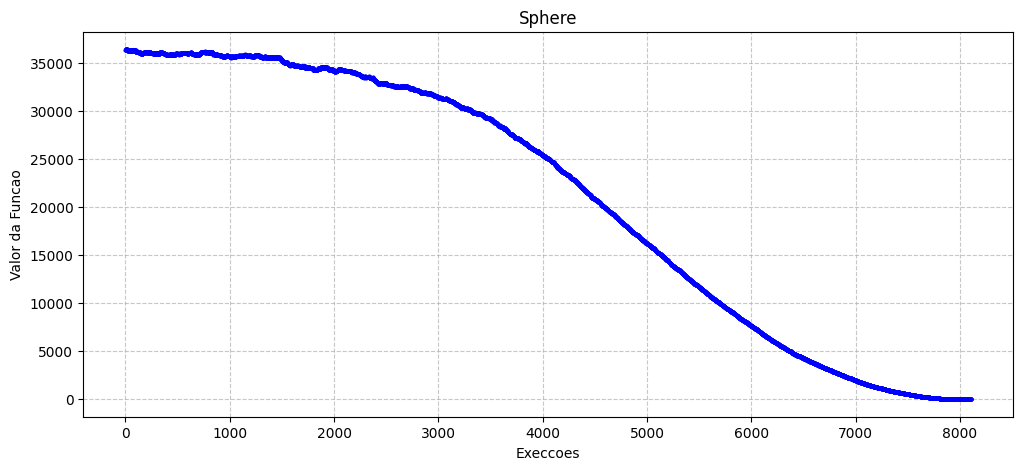

In [10]:
# Para Sphere (já funcionando)
plt.figure(figsize=(12, 5))

# Lembrando que c é o histórico de avaliações (DA ULTIMA RODADA OBVIAMENTE!!) (ISSO TUDO DO SIMULATED ANNEALING)
plt.plot(c, 'b-o', markersize=2)
plt.title('Sphere')
plt.xlabel('Execcoes')
plt.ylabel('Valor da Funcao')
plt.grid(True, linestyle='--', alpha=0.7)
#plt.yscale('log')  # Talvez eu precise ativar a escala aqui
plt.show()

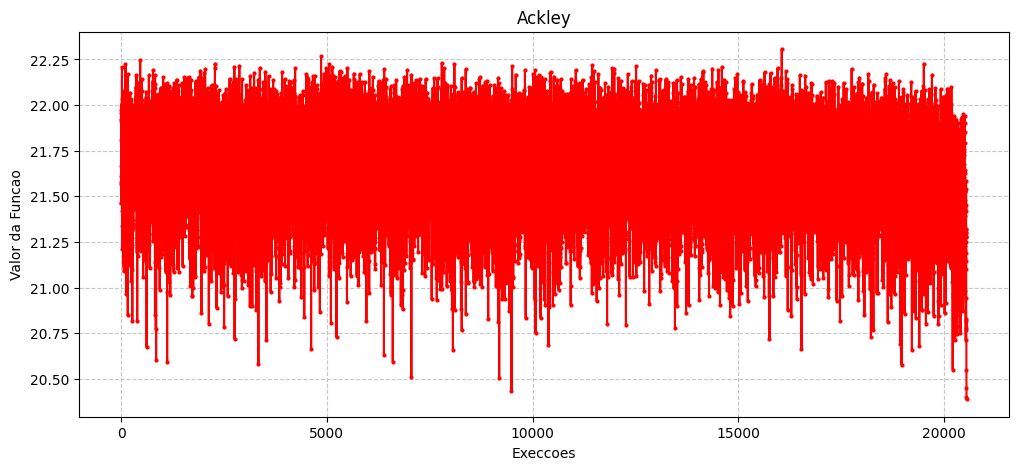

In [11]:
# # Para Ackley
plt.figure(figsize=(12, 5))

# Lembrando que c2 é o histórico de avaliações (DA ULTIMA RODADA OBVIAMENTE!!) (ISSO TUDO DO SIMULATED ANNEALING)
plt.plot(c2, 'r-o', markersize=2)  
plt.title('Ackley')
plt.xlabel('Execcoes')
plt.ylabel('Valor da Funcao')
plt.grid(True, linestyle='--', alpha=0.7)
#plt.yscale('linear')  # Talvez eu precise ativar a escala aqui

plt.show()

# Hyperparâmetros
### Sphere
- HC: step_size=0.5, p=0.1
- SA: step_size=0.1, cooling_rate=0.999, initial_temp = 1000

### Ackley
- HC: Tanto faz
- SA: Tanto faz

# Teste Wilcoxon

In [19]:
display(resultados_sphere[:5])
display(resultados_simulated[:5])

[9.319003586648509e-07,
 2.5554435490110835e-06,
 2.8308054759776633e-06,
 5.354632795580354e-06,
 8.251496664398297e-07]

[0.006364275461958011,
 0.011624298747686355,
 0.0112290784355728,
 0.005461694448651128,
 0.007869809020012532]

In [20]:
display(resultados_ack[:5])
display(resultados_simulated2[:5])

[array([20.00508905]),
 array([20.002994]),
 array([20.01310521]),
 array([20.00000904]),
 array([20.00556934])]

[array([20.46027012]),
 array([20.25031381]),
 array([20.32093752]),
 array([20.48038867]),
 array([20.15570685])]

In [14]:
from scipy import stats
print(f"Sphere: {stats.wilcoxon(resultados_sphere,resultados_simulated)}")
print(f"Ackley: {stats.wilcoxon(resultados_ack,resultados_simulated2)}")

Sphere: WilcoxonResult(statistic=0.0, pvalue=1.9073486328125e-06)
Ackley: WilcoxonResult(statistic=array([20.]), pvalue=array([0.00070763]))


# Resultados
1. O hill climbing (HC) para funções relativamente simples é muito bom! (Como a sphere)

2. O Simulated Annealing (SA) para funções simples é bom tambem...mas talvez ele brilhe em funções um pouco mais complexas! Não tão simples como a sphere, mas também não tão complexas como o Ackley! (Talvez o fato de estarmos com um X de 10D e de -100 a 100...testei ele com um vetor de 3 e 2 e ele foi BEM melhor)

3. Infelizmente nenhum dos dois vai funcionar na Ackley! 